# Audio Metamer Spectrograms

This notebook loads saved audio metamer outputs and visualizes one selected example as spectrograms.

Expected folder layout:
- `experiments/audio/<model>/metamers/<layer>/metadata.jsonl`
- `idxXXXX_<label>_original.wav`
- `idxXXXX_<label>_metamer.wav`

It supports:
- a focused single-model view (original + all layers)
- an all-model overview for one sample index

In [1]:
from pathlib import Path
import json
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
from scipy.io import wavfile
from IPython.display import Audio, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS_ROOT = PROJECT_ROOT / "experiments" / "audio"

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"RESULTS_ROOT={RESULTS_ROOT}")

PROJECT_ROOT=/orcd/data/jhm/001/om2/rphess/projects/github.com/model_metamers_pytorch
RESULTS_ROOT=/orcd/data/jhm/001/om2/rphess/projects/github.com/model_metamers_pytorch/experiments/audio


In [2]:
def _read_jsonl(path: Path):
    records = []
    if not path.exists():
        return records
    with path.open("r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            records.append(json.loads(line))
    return records


def _wav_paths_for_sample(layer_dir: Path, sample_idx: int, class_label: str):
    prefix = f"idx{int(sample_idx):04d}_{class_label}"
    return (
        layer_dir / f"{prefix}_original.wav",
        layer_dir / f"{prefix}_metamer.wav",
    )


def discover_audio_metamers(results_root: Path):
    data = defaultdict(lambda: defaultdict(dict))
    summary = {
        "models": [],
        "sample_indices": set(),
        "pairs_found": 0,
    }

    if not results_root.exists():
        return data, summary

    for model_dir in sorted([p for p in results_root.iterdir() if p.is_dir()]):
        metamer_root = model_dir / "metamers"
        if not metamer_root.exists():
            continue
        summary["models"].append(model_dir.name)

        for layer_dir in sorted([p for p in metamer_root.iterdir() if p.is_dir()]):
            records = _read_jsonl(layer_dir / "metadata.jsonl")
            for rec in records:
                sample_idx = int(rec["sample_idx"])
                class_label = rec.get("class_label", "audioset")
                original_wav, metamer_wav = _wav_paths_for_sample(layer_dir, sample_idx, class_label)
                if not (original_wav.exists() and metamer_wav.exists()):
                    continue

                source_info = rec.get("source_info", {})
                data[model_dir.name][sample_idx][layer_dir.name] = {
                    "layer": layer_dir.name,
                    "original_wav": original_wav,
                    "metamer_wav": metamer_wav,
                    "sample_rate": int(rec.get("sample_rate", rec.get("file_sr", 16000))),
                    "class_label": class_label,
                    "ytid": source_info.get("ytid", None),
                    "metadata": rec,
                }
                summary["sample_indices"].add(sample_idx)
                summary["pairs_found"] += 1

    summary["sample_indices"] = sorted(summary["sample_indices"])
    return data, summary

In [3]:
catalog, catalog_summary = discover_audio_metamers(RESULTS_ROOT)

if not catalog_summary["models"] or catalog_summary["pairs_found"] == 0:
    print("No generated audio metamer files were found.")
    print("Expected outputs under:", RESULTS_ROOT)
    print("Generate them with generate_audio_metamers.sh (or scripts/generate_metamers.py --modality audio).")
else:
    print("Discovered models:", ", ".join(catalog_summary["models"]))
    print("Sample indices:", catalog_summary["sample_indices"][:20], "..." if len(catalog_summary["sample_indices"]) > 20 else "")
    print("Total original/metamer layer pairs:", catalog_summary["pairs_found"])

Discovered models: audiomae_as2m, audiomae_as2m_ft_as20k, beats_iter3, beats_iter3_plus_as2m, clap
Sample indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] 
Total original/metamer layer pairs: 550


In [15]:
# Editable selectors
MODEL_NAME = "clap"  # e.g. "clap"; None -> first discovered model
SAMPLE_IDX = None   # e.g. 0; None -> first sample available for the selected model
MAX_LAYERS = None   # e.g. 8 for compact figures


def choose_model_and_sample(catalog_data, model_name=None, sample_idx=None):
    if not catalog_data:
        raise RuntimeError("No catalog data found.")

    all_models = sorted(catalog_data.keys())
    chosen_model = model_name if model_name is not None else all_models[0]
    if chosen_model not in catalog_data:
        raise ValueError(f"Model '{chosen_model}' not found. Available: {all_models}")

    sample_keys = sorted(catalog_data[chosen_model].keys())
    if not sample_keys:
        raise RuntimeError(f"Model '{chosen_model}' has no samples with wav pairs.")
    chosen_sample = int(sample_idx) if sample_idx is not None else sample_keys[0]
    if chosen_sample not in catalog_data[chosen_model]:
        raise ValueError(
            f"Sample {chosen_sample} not present for model '{chosen_model}'. Available: {sample_keys[:20]}"
        )
    return chosen_model, chosen_sample

In [13]:
def load_wav_mono_float(path: Path):
    sr, x = wavfile.read(path)
    x = np.asarray(x)
    if x.ndim == 2:
        x = x.mean(axis=1)

    if np.issubdtype(x.dtype, np.integer):
        info = np.iinfo(x.dtype)
        denom = max(abs(info.min), info.max)
        x = x.astype(np.float32) / float(denom)
    else:
        x = x.astype(np.float32)

    x = np.clip(x, -1.0, 1.0)
    return sr, x


def compute_log_mel(waveform_np, sample_rate, n_fft=1024, hop_length=256, n_mels=128):
    mel = torchaudio.transforms.MelSpectrogram(
        sample_rate=int(sample_rate),
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0,
    )
    wav_t = torch.from_numpy(waveform_np).float().unsqueeze(0)
    m = mel(wav_t).squeeze(0)
    return torch.log10(torch.clamp(m, min=1e-10)).cpu().numpy()


def _extract_trailing_int(name):
    tail = name.rsplit("_", 1)[-1]
    return int(tail) if tail.isdigit() else 0


def _layer_sort_key(layer_name):
    # Order by processing stage, not alphabetical naming.
    if layer_name == "vit_patch_embeddings":
        return (0, 0, layer_name)
    if layer_name.startswith("input"):
        return (0, 1, layer_name)
    if layer_name in {"tokens", "cls_token", "patch_tokens", "patch_features", "projected_features"}:
        return (1, 0, layer_name)
    if layer_name.startswith("transformer_block_"):
        return (2, _extract_trailing_int(layer_name), layer_name)
    if layer_name.startswith("transformer_layer_"):
        return (2, _extract_trailing_int(layer_name), layer_name)
    if layer_name.startswith("hidden_state_"):
        return (3, _extract_trailing_int(layer_name), layer_name)
    if layer_name in {"pooler_output", "final_pooled_embedding", "final_audio_embedding", "audio_embeds"}:
        return (4, 0, layer_name)
    if layer_name in {"last_hidden_state", "final"}:
        return (5, 0, layer_name)
    return (99, 0, layer_name)


def _layer_items_for_model(catalog_data, model_name, sample_idx, max_layers=None):
    layer_dict = catalog_data[model_name][sample_idx]
    layers = sorted(layer_dict.keys(), key=_layer_sort_key)
    if max_layers is not None:
        layers = layers[: int(max_layers)]
    return [(layer, layer_dict[layer]) for layer in layers]

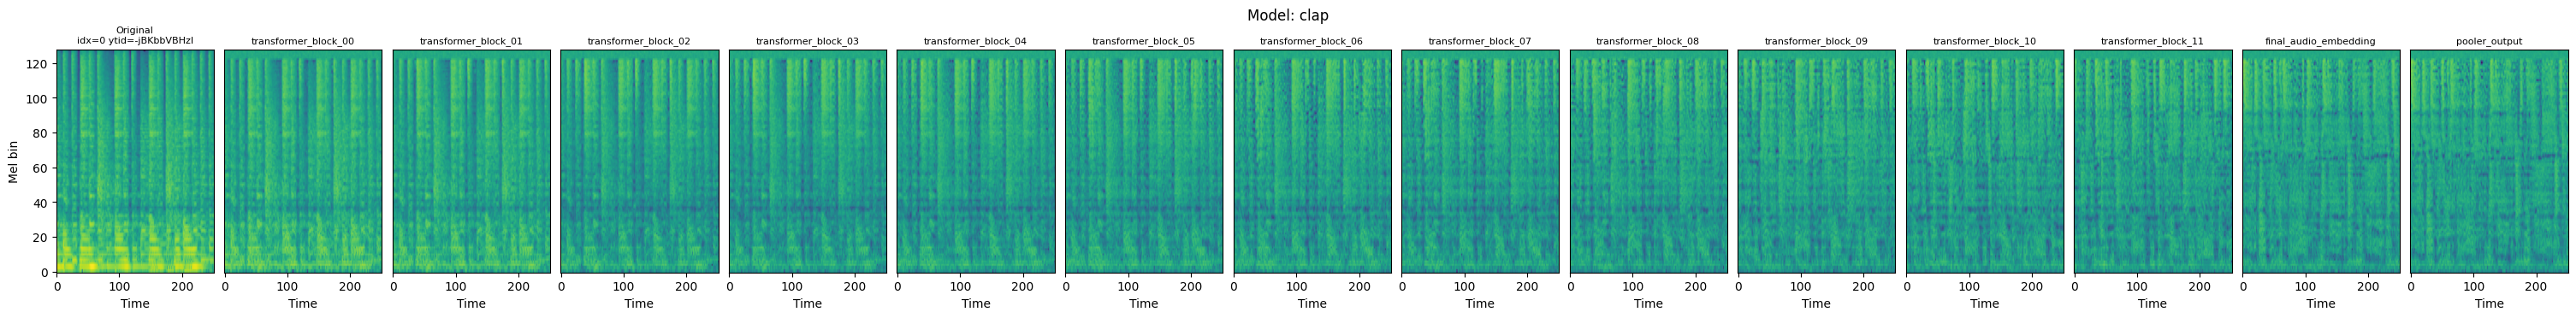

In [16]:
def plot_single_model_spectrograms(catalog_data, model_name=None, sample_idx=None, max_layers=None, figsize_per_panel=2.0):
    model_name, sample_idx = choose_model_and_sample(catalog_data, model_name, sample_idx)
    layer_items = _layer_items_for_model(catalog_data, model_name, sample_idx, max_layers=max_layers)
    if not layer_items:
        raise RuntimeError("No layers found for selected model/sample.")

    first = layer_items[0][1]
    sr0, orig = load_wav_mono_float(first["original_wav"])
    orig_spec = compute_log_mel(orig, sr0)

    ncols = 1 + len(layer_items)
    fig, axes = plt.subplots(
        1,
        ncols,
        figsize=(max(4, ncols * figsize_per_panel), 3.4),
        squeeze=False,
        constrained_layout=True,
    )
    axes = axes[0]

    axes[0].imshow(orig_spec, origin="lower", aspect="auto")
    ytid = first.get("ytid", None)
    prefix = f"idx={sample_idx}"
    if ytid:
        prefix += f" ytid={ytid}"
    axes[0].set_title(f"Original\n{prefix}", fontsize=8)
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Mel bin")

    vmin, vmax = orig_spec.min(), orig_spec.max()
    for i, (layer_name, entry) in enumerate(layer_items, start=1):
        sr, met = load_wav_mono_float(entry["metamer_wav"])
        met_spec = compute_log_mel(met, sr)
        axes[i].imshow(met_spec, origin="lower", aspect="auto", vmin=vmin, vmax=vmax)
        axes[i].set_title(layer_name, fontsize=8)
        axes[i].set_xlabel("Time")
        axes[i].set_yticks([])

    fig.suptitle(f"Model: {model_name}", y=1.05)
    return model_name, sample_idx, layer_items


if catalog_summary["pairs_found"] > 0:
    selected_model, selected_sample, selected_layers = plot_single_model_spectrograms(
        catalog,
        model_name=MODEL_NAME,
        sample_idx=SAMPLE_IDX,
        max_layers=MAX_LAYERS,
    )
else:
    selected_model, selected_sample, selected_layers = None, None, []

In [7]:
def plot_all_models_overview(catalog_data, sample_idx=None, max_layers=None, cols=4, panel_size=(3.0, 2.5)):
    models_with_sample = []
    for model_name in sorted(catalog_data.keys()):
        sample_keys = sorted(catalog_data[model_name].keys())
        if not sample_keys:
            continue
        chosen_sample = int(sample_idx) if sample_idx is not None else sample_keys[0]
        if chosen_sample in catalog_data[model_name]:
            models_with_sample.append((model_name, chosen_sample))

    if not models_with_sample:
        raise RuntimeError("No models contain the requested sample index.")

    panel_entries = []
    for model_name, chosen_sample in models_with_sample:
        layer_items = _layer_items_for_model(catalog_data, model_name, chosen_sample, max_layers=max_layers)
        if not layer_items:
            continue
        first = layer_items[0][1]
        panel_entries.append((f"{model_name}\noriginal", first["original_wav"]))
        for layer_name, entry in layer_items:
            panel_entries.append((f"{model_name}\n{layer_name}", entry["metamer_wav"]))

    n = len(panel_entries)
    cols = min(cols, n)
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * panel_size[0], rows * panel_size[1]),
        squeeze=False,
        constrained_layout=True,
    )
    axes = axes.reshape(-1)

    for ax in axes[n:]:
        ax.axis("off")

    for ax, (title, wav_path) in zip(axes[:n], panel_entries):
        sr, wav = load_wav_mono_float(wav_path)
        spec = compute_log_mel(wav, sr)
        ax.imshow(spec, origin="lower", aspect="auto")
        ax.set_title(title, fontsize=8)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle("All-model metamer spectrogram overview", y=1.02)
    return models_with_sample, panel_entries


# Uncomment to render the all-model overview
# if catalog_summary["pairs_found"] > 0:
#     _models_with_sample, _panel_entries = plot_all_models_overview(
#         catalog,
#         sample_idx=SAMPLE_IDX,
#         max_layers=MAX_LAYERS,
#     )

In [8]:
def display_audio_for_selected_layers(layer_items, max_to_play=3):
    if not layer_items:
        print("No selected layers to play.")
        return

    first = layer_items[0][1]
    sr_o, wav_o = load_wav_mono_float(first["original_wav"])
    print("Original")
    display(Audio(data=wav_o, rate=sr_o))

    for layer_name, entry in layer_items[: int(max_to_play)]:
        sr_m, wav_m = load_wav_mono_float(entry["metamer_wav"])
        print(f"Metamer: {layer_name}")
        display(Audio(data=wav_m, rate=sr_m))


if selected_layers:
    display_audio_for_selected_layers(selected_layers, max_to_play=3)

Original


Metamer: vit_patch_embeddings


Metamer: transformer_block_00


Metamer: transformer_block_01
